# Survival Analysis

Kaplan-Meier survival curves (overall + stratified) with log-rank tests,
and a Cox proportional hazards model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import INTERIM_DIR
from churn.survival.prep import prepare_survival_data

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

subscriber_static = pd.read_parquet(INTERIM_DIR / "subscriber_static.parquet")

## 1. Survival data preparation

- **Duration**: tenure in days (`date_activation` → `churn_date` if churned, else censoring reference date)
- **Event**: 1 = churned (observed), 0 = censored (still active as of the reference date)
- **Censoring reference date**: max observed date across `churn_date`/`last_call_date` — not limited to the 7-month usage window, since this analysis doesn't use `monthly_agg`

In [2]:
survival_df = prepare_survival_data(subscriber_static)

Survival data prepared: 423766 subscribers (0 dropped for negative duration — activation after event/reference date)
Censoring reference date: 2025-03-19 23:59:59
Event rate: 8.56%
            duration          event
count  423766.000000  423766.000000
mean     1756.552928       0.085557
std      1955.826083       0.279709
min         0.000000       0.000000
25%       264.000000       0.000000
50%       971.000000       0.000000
75%      2515.000000       0.000000
max      8119.000000       1.000000


## 2. Kaplan-Meier — overall survival

inf


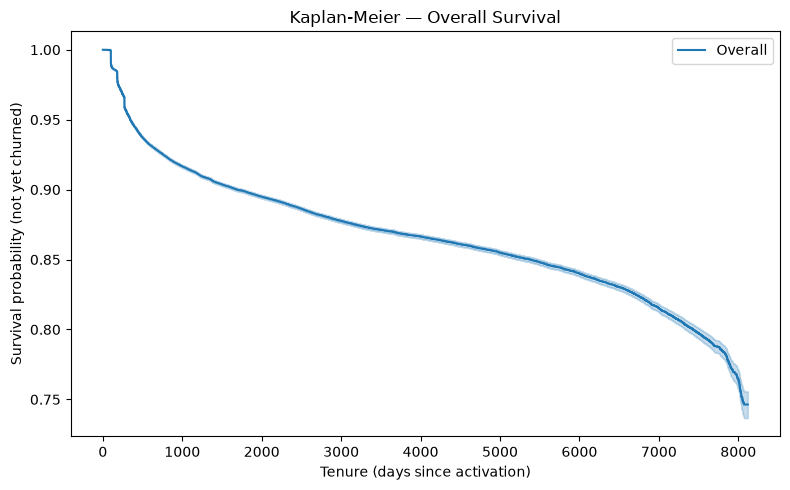

In [3]:
from churn.survival.kaplan_meier import fit_overall_km, plot_overall_km

kmf_overall = fit_overall_km(survival_df)
print(kmf_overall.median_survival_time_)

fig = plot_overall_km(kmf_overall)
save_fig(fig, "survival_01_overall_km")
plt.show()

- **The median survival time is not reached.** The survival probability remains well above 50% throughout the observed follow-up period (ending around 74%), meaning more than half of subscribers are still active at the end of observation. This is consistent with the relatively low overall churn rate (8.56%).

- **The survival curve shows a gradual decline rather than a sharp drop.**  This suggests that while some customers churn relatively early, most remain active for many years and churn accumulates progressively over time rather than occurring at one specific tenure.

## 3. Kaplan-Meier by group + log-rank tests

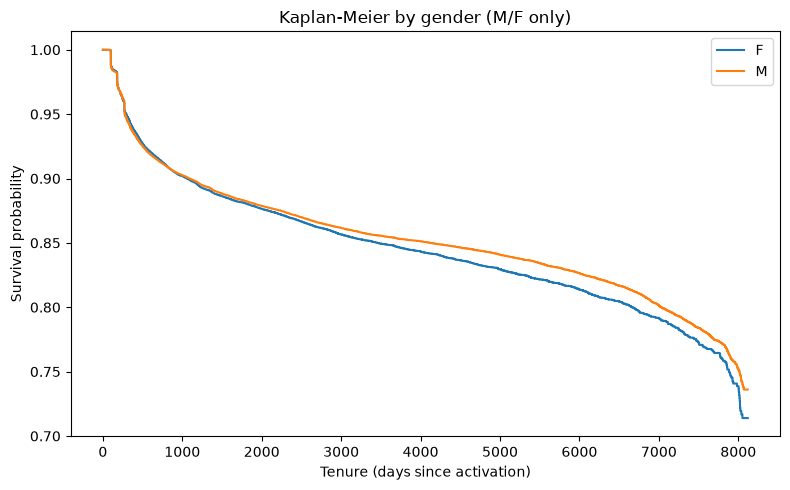


--- Log-rank test: gender ---
test statistic: 5.85, p-value: 0.05366


In [4]:
from churn.survival.kaplan_meier import fit_km_by_group, plot_km_by_group, run_logrank_test, add_age_bucket

# "U" (unknown) has only ~9 subscribers -- too small to plot meaningfully
# next to M/F, so it's excluded from THIS chart only (fit_km_by_group itself
# is untouched). The log-rank test below is intentionally left as-is,
# still covering all 3 groups (M/F/U) -- see the markdown note after this
# section for why.
survival_df_mf = survival_df[survival_df["gender"] != "U"]
fitters_gender = fit_km_by_group(survival_df_mf, "gender")
fig = plot_km_by_group(fitters_gender, "Kaplan-Meier by gender (M/F only)", ci_show=False)
save_fig(fig, "survival_02_km_by_gender")
plt.show()
run_logrank_test(survival_df, "gender")

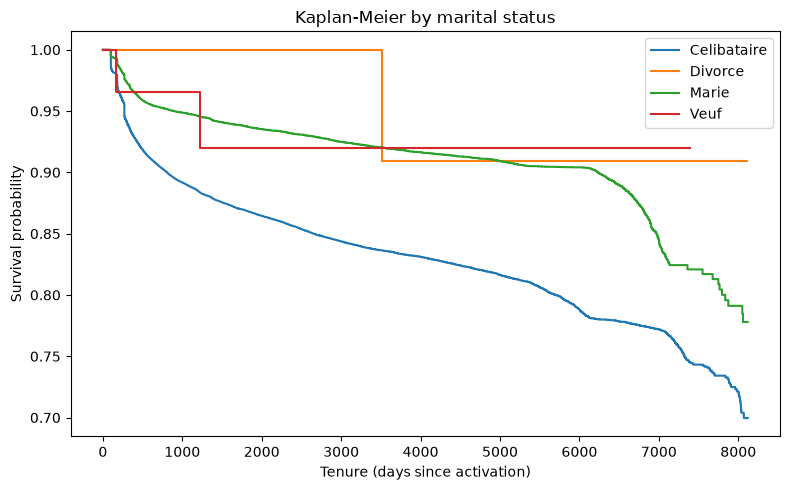


--- Log-rank test: marital_status ---
test statistic: 1689.97, p-value: 0


In [5]:
fitters_marital = fit_km_by_group(survival_df, "marital_status")
fig = plot_km_by_group(fitters_marital, "Kaplan-Meier by marital status", ci_show=False)
save_fig(fig, "survival_03_km_by_marital_status")
plt.show()
run_logrank_test(survival_df, "marital_status")

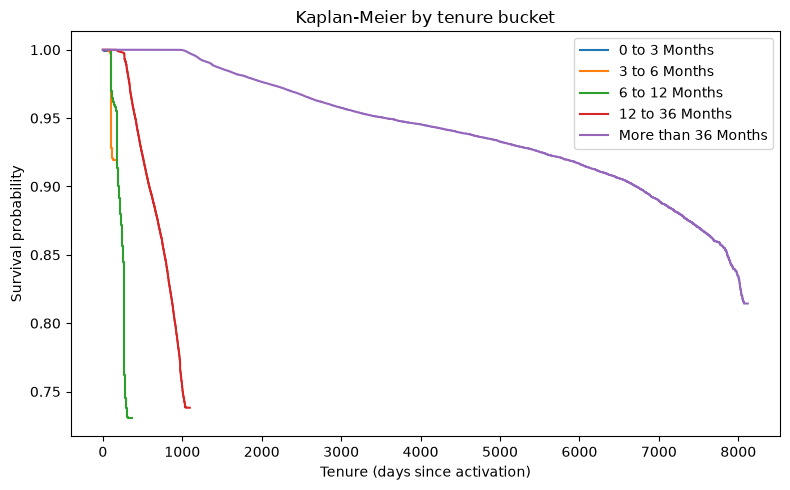


--- Log-rank test: classe_anciennete ---
test statistic: 86729.84, p-value: 0


In [6]:
fitters_tenure = fit_km_by_group(survival_df, "classe_anciennete", order=[
    "0 to 3 Months", "3 to 6 Months", "6 to 12 Months", "12 to 36 Months", "More than 36 Months"
])
fig = plot_km_by_group(fitters_tenure, "Kaplan-Meier by tenure bucket",ci_show=False)
save_fig(fig, "survival_04_km_by_tenure")
plt.show()
run_logrank_test(survival_df, "classe_anciennete")

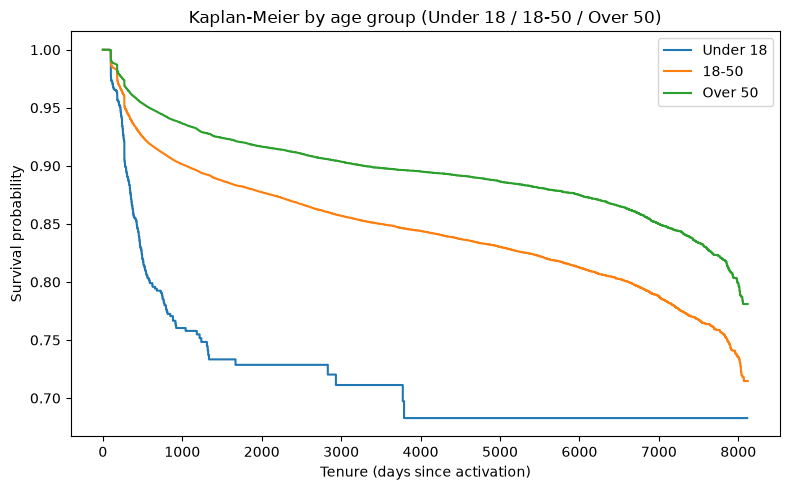


--- Log-rank test: age_group_3 ---
test statistic: 1500.11, p-value: 0


In [7]:
valid_age = survival_df.dropna(subset=["age"]).copy()
max_age = int(valid_age["age"].max())
# pd.cut is right-closed by default: bin edges are (0,18], (18,50], (50,max_age].
# In practice this means age==18 groups into "Under 18" and age==50 groups
# into "18-50" -- a single-year boundary effect, noted here rather than left
# silently ambiguous.
valid_age["age_group_3"] = pd.cut(
    valid_age["age"], bins=[0, 18, 50, max_age],
    labels=["Under 18", "18-50", "Over 50"], include_lowest=True,
)

fitters_age3 = fit_km_by_group(valid_age, "age_group_3", order=["Under 18", "18-50", "Over 50"])
fig = plot_km_by_group(fitters_age3, "Kaplan-Meier by age group (Under 18 / 18-50 / Over 50)", ci_show=False)
save_fig(fig, "survival_05_km_by_age")
plt.show()
run_logrank_test(valid_age, "age_group_3")

**Interpretation:**

- **Gender:** Male and female survival curves almost overlap, indicating similar churn behavior. This agrees with the EDA, and the log-rank test (p = 0.054) shows the difference is not statistically significant. The "U" category is too small (n = 9) to interpret, so it's excluded from the plot above — but the log-rank test itself is intentionally left covering all 3 groups (M/F/U), since dropping a 9-subscriber group from a 423k-row test has no meaningful effect on the M-vs-F comparison, and this keeps the test result consistent with what's reported elsewhere for this variable.

- **Marital status:** Single subscribers have lower survival than married subscribers, indicating higher churn risk. Divorced and widowed groups are too small for reliable conclusions. The log-rank test (p < 0.001) confirms significant differences between marital status groups.

- **Tenure bucket:** The Kaplan-Meier curves confirm the EDA results: among tenure buckets with enough accumulated follow-up to compare meaningfully, subscribers with more than 36 months of tenure have the highest survival and those with 6–12 months have the highest churn risk (log-rank p < 0.001). The 0–3 month bucket shows an even lower observed event rate, but that's an artifact of its duration being capped at 90 days by construction (too little follow-up time to observe churn), not genuinely lower risk.

- **Age group (3 buckets: Under 18 / 18-50 / Over 50):** Survival increases monotonically with age group — Under 18 has the lowest survival (13.8% observed event rate), 18-50 is in the middle (9.5%), and Over 50 has the highest survival (7.6%). The log-rank test (statistic = 1500.11, p < 0.001) confirms these differences are statistically significant. This is consistent with both the EDA and the previous 5-bucket version of this chart (which also found the youngest group riskiest), just at a coarser resolution.

## 4. Cox Proportional Hazards model

Covariates: age, gender, marital_status, customer_language, classe_anciennete.
`contact_city` excluded (unresolved high-cardinality/messiness from EDA).

Dropped 20683 rows with missing age (Cox requires complete covariates)


C:\Users\tagho\churn-prediction\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['gender_U', 'marital_status_Divorce', 'marital_status_Veuf'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


                                       hazard_ratio      coef              p  \
covariate                                                                      
classe_anciennete_More than 36 Months      0.000099 -9.215900  1.244541e-204   
classe_anciennete_12 to 36 Months          0.017128 -4.067066   2.080144e-42   
classe_anciennete_6 to 12 Months           0.205259 -1.583483   1.006543e-07   
gender_Missing                             0.317871 -1.146111  3.878523e-140   
customer_language_Arabe                    0.481039 -0.731807  2.622726e-100   
classe_anciennete_3 to 6 Months            0.501378 -0.690396   2.017517e-02   
gender_U                                   1.965227  0.675608   4.995113e-01   
marital_status_Divorce                     0.593530 -0.521667   6.020346e-01   
marital_status_Veuf                        1.461148  0.379223   5.919653e-01   
marital_status_Marie                       1.449146  0.370974   1.266052e-24   
customer_language_Français              

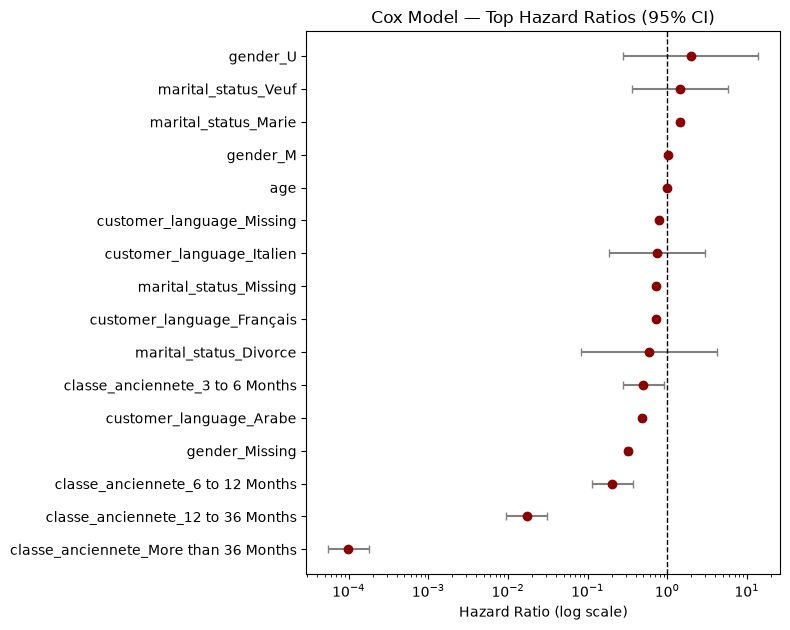

In [8]:
from churn.survival.cox_model import prepare_cox_data, fit_cox_model, get_top_hazard_ratios, plot_hazard_ratios

cox_df = prepare_cox_data(survival_df)
cph = fit_cox_model(cox_df)

top_hr = get_top_hazard_ratios(cph, top_n=20)
print(top_hr)

fig = plot_hazard_ratios(top_hr)
save_fig(fig, "survival_06_cox_hazard_ratios")
plt.show()

**Interpretation**

HR > 1 indicates a higher churn risk than the reference group, while HR < 1 indicates a lower churn risk.

*(Note: `top_n=20` now returns all 16 covariates the Cox model actually has — there aren't 20 to show. The 4 newly-visible ones below were previously cut off at `top_n=12`.)*

- **Tenure is the strongest predictor of churn.** Subscribers with longer tenure have a much lower churn risk than the 0–3 month reference group, confirming the EDA and Kaplan-Meier results that long-term customers are more loyal. The magnitudes here are extreme (e.g. HR ≈ 0.0001 for >36 months) because classe_anciennete's bucket boundaries mechanically cap how much follow-up time each group can contribute (see the Kaplan-Meier section) — treat the direction as reliable, not the precise hazard-ratio magnitude.

- **Customer language also has an independent effect.** Arabic- and French-speaking subscribers have a lower churn risk than the reference group (Anglais).

- **Marital status.** While Kaplan-Meier suggests married subscribers have better survival, the Cox model (reference: `Celibataire`) shows `Marie` with a higher hazard (HR ≈ 1.45). This difference is explained by **tenure**: married subscribers are generally longer-tenured (median tenure 2814 days vs. 887 days for single subscribers), and long tenure strongly reduces churn risk. Once tenure is accounted for, the apparent advantage disappears. Divorced and widowed groups are too small for reliable interpretation.

- **Missing demographic values are informative, not random (MNAR).** Subscribers with missing gender or marital status have a lower churn risk here, confirming that missingness itself carries signal rather than being random noise. In the actual feature-preparation pipeline (`churn.selection.prepare`), gender and marital_status are mode-imputed (fit on training data only) rather than kept as their own category — unlike `customer_language`, whose missing values are instead kept as an explicit `"Missing"` category. The three fields aren't treated uniformly: `customer_language`'s mode (`Anglais`) is itself the highest-churn language group, so imputing missing values with it would inject that specific risk profile onto unrelated customers rather than making a neutral guess. Gender and marital_status don't have that same complication, so mode-imputation is a reasonably neutral default for them.

- **Newly visible at top_n=20 (ranks 13–16 of 16):** `customer_language_Italien` (HR ≈ 0.75, p = 0.68 — not significant; consistent with its small sample size, n = 94, already flagged as unreliable in the EDA), `customer_language_Missing` (HR ≈ 0.79, p < 0.001 — significant, same missing-is-informative pattern as gender/marital_status above), `gender_M` (HR ≈ 1.01, p = 0.40 — not significant, negligible effect, consistent with the gender log-rank test above), and `age` (HR ≈ 0.9968 per year, p < 0.001 — statistically significant but tiny in practice: about a 0.3% hazard reduction per additional year of age). None of these four changes the overall picture: tenure dominates, and the demographic effects are secondary.

## 5. Individual survival / cumulative hazard prediction

Illustrative only — uses the already-fitted `CoxPHFitter` (`cph`) from Section 4
directly, on the same population survival model, not the separate
churn-prediction pipeline in `src/churn/modeling`. No leakage concern, since
nothing here feeds back into that pipeline.

The example is a random **currently-active (censored, not yet churned)**
subscriber from the Cox model's own fitted population, drawn with a fixed
seed for reproducibility. An active subscriber is the more useful framing
here than a subscriber who already churned — the resulting curves read as
"what the model predicts going forward for someone still with us," which is
the actual use case for this kind of individual-level prediction.

Example subscriber's covariate profile:
                                      345824
duration                                1298
event                                      0
age                                     46.0
gender_M                                True
gender_Missing                         False
gender_U                               False
marital_status_Divorce                 False
marital_status_Marie                   False
marital_status_Missing                 False
marital_status_Veuf                    False
customer_language_Arabe                False
customer_language_Français             False
customer_language_Italien              False
customer_language_Missing              False
classe_anciennete_12 to 36 Months      False
classe_anciennete_3 to 6 Months        False
classe_anciennete_6 to 12 Months       False
classe_anciennete_More than 36 Months   True


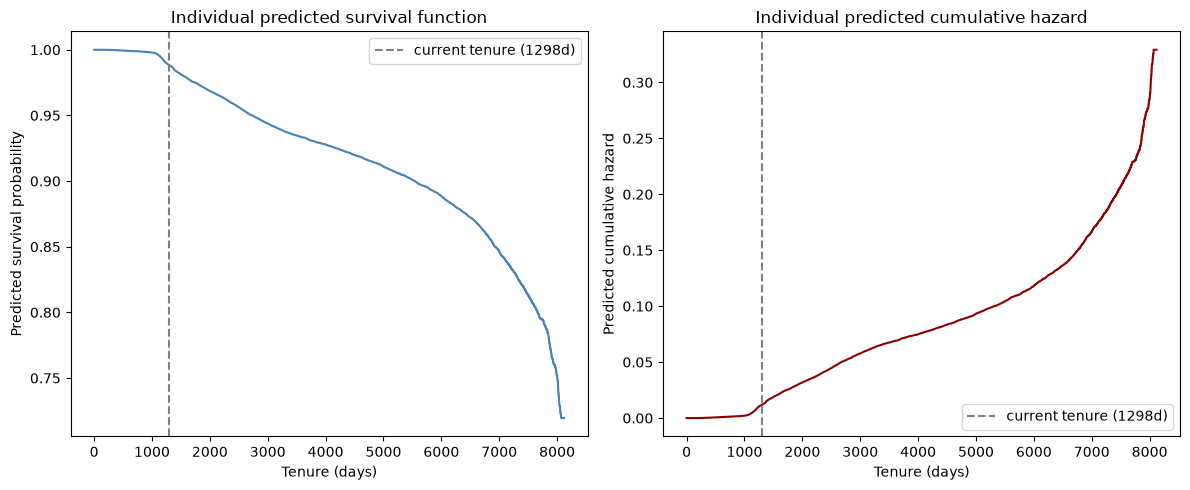

In [9]:
example = cox_df[cox_df["event"] == 0].sample(n=1, random_state=42)
example_covariates = example.drop(columns=["duration", "event"])
example_tenure = float(example["duration"].iloc[0])

print("Example subscriber's covariate profile:")
print(example.T)

sf = cph.predict_survival_function(example_covariates)
ch = cph.predict_cumulative_hazard(example_covariates)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sf.index, sf.iloc[:, 0], color="steelblue")
axes[0].axvline(example_tenure, color="gray", linestyle="--", label=f"current tenure ({example_tenure:.0f}d)")
axes[0].set_xlabel("Tenure (days)")
axes[0].set_ylabel("Predicted survival probability")
axes[0].set_title("Individual predicted survival function")
axes[0].legend()

axes[1].plot(ch.index, ch.iloc[:, 0], color="darkred")
axes[1].axvline(example_tenure, color="gray", linestyle="--", label=f"current tenure ({example_tenure:.0f}d)")
axes[1].set_xlabel("Tenure (days)")
axes[1].set_ylabel("Predicted cumulative hazard")
axes[1].set_title("Individual predicted cumulative hazard")
axes[1].legend()

plt.tight_layout()
save_fig(fig, "survival_07_individual_prediction")
plt.show()

**Interpretation — Individual prediction**

The example subscriber: **46 years old, male, single (`Celibataire`), English-speaking (`Anglais`), tenure bucket "More than 36 Months"** (current tenure = 1298 days, ≈3.6 years), currently active (censored, not churned).

- **At their current tenure (1298 days), predicted survival is 98.8%** (cumulative hazard 0.012) — very low near-term risk, consistent with this subscriber's "More than 36 Months" bucket already having the strongest protective hazard ratio in the model (Section 4).
- **Both curves decline further out, though.** By 8119 days (the longest tenure in the dataset), predicted survival has fallen to 72.0% (cumulative hazard 0.33) — not flat, but declining at a similar overall shape to the population-level curve in Section 2 (which ends around 74%). So "protective" here means low *near-term* risk given their current tenure, not zero risk indefinitely.
- **The vertical marker (current tenure, 1298 days) sits early on both curves**, well before most of the predicted decline happens — this subscriber has already survived the highest-risk early-tenure period the population-level curves show in Section 3.
- **This individual's other attributes (single, Anglais-speaking) are each mildly risk-elevating** on their own (Section 4), but their effect is small next to the tenure effect — illustrating why tenure dominates the model's predictions for any individual, not just at the population level.